## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Model persistence
import joblib

# Path handling
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load dataset
data_path = Path('../../../data/raw/house_prices/homeprices.csv')
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully!

Dataset shape: (30, 2)
Rows: 30, Columns: 2


In [3]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000
5,4100,750000
6,2600,550000
7,2900,560000
8,3100,580000
9,3300,620000


In [4]:
# Basic information about dataset
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    30 non-null     int64
 1   price   30 non-null     int64
dtypes: int64(2)
memory usage: 612.0 bytes


In [5]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,area,price
count,30.000000,30.000000
mean,3500.000000,662766.666667
std,515.283651,81853.394315
min,2600.000000,550000.000000
25%,3112.500000,583750.000000
50%,3525.000000,660000.000000
75%,3937.500000,728750.000000
max,4300.000000,800000.000000


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\n✅ No missing values found!")
else:
    print("\n⚠️ Missing values detected!")

Missing Values:
area     0
price    0
dtype: int64

✅ No missing values found!


## 3. Data Visualization

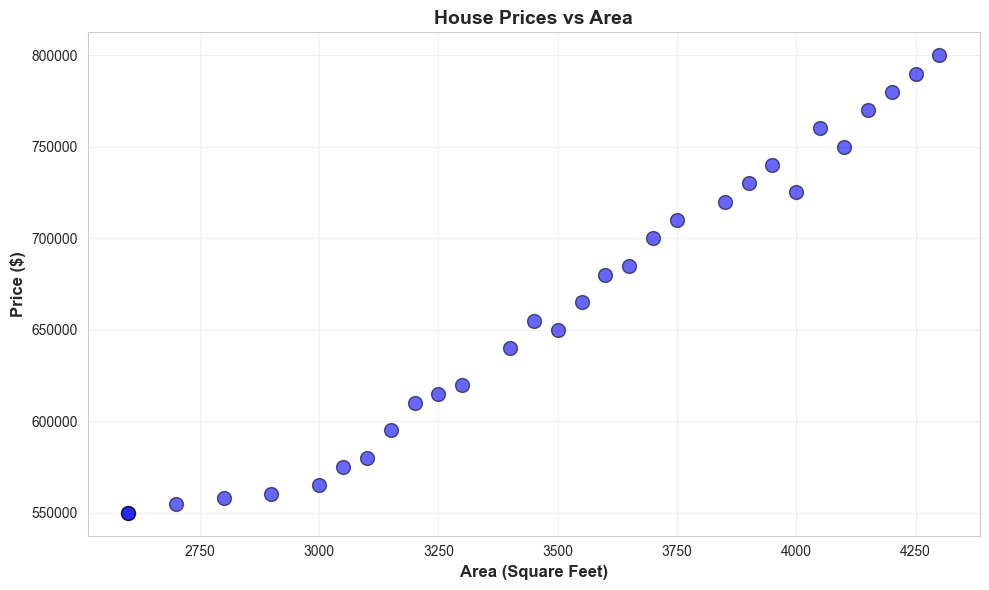

📊 The plot shows a positive linear relationship between area and price.


In [7]:
# Scatter plot: Area vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df['area'], df['price'], color='blue', alpha=0.6, s=100, edgecolors='black')
plt.xlabel('Area (Square Feet)', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.title('House Prices vs Area', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 The plot shows a positive linear relationship between area and price.")

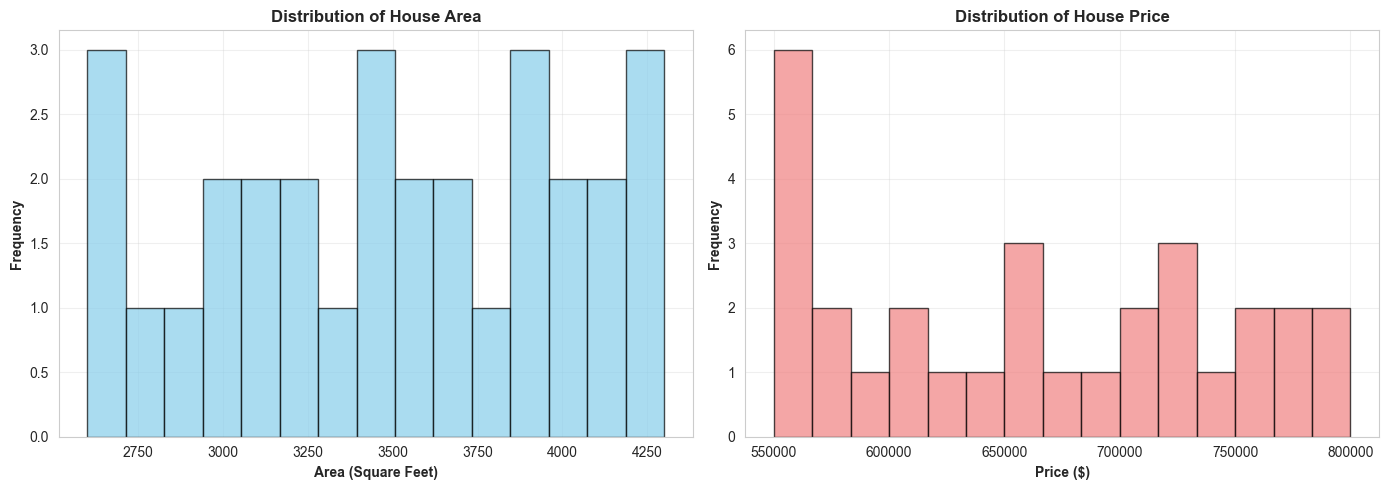

In [8]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Area distribution
axes[0].hist(df['area'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Area (Square Feet)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of House Area', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Price distribution
axes[1].hist(df['price'], bins=15, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Price ($)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of House Price', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Correlation analysis
correlation = df['area'].corr(df['price'])
print(f"Correlation between Area and Price: {correlation:.4f}")

if correlation > 0.9:
    print("✅ Very strong positive correlation!")
elif correlation > 0.7:
    print("✅ Strong positive correlation!")
else:
    print("⚠️ Moderate correlation")

Correlation between Area and Price: 0.9879
✅ Very strong positive correlation!


## 4. Prepare Data for Training

In [10]:
# Separate features and target
X = df[['area']]  # Features (must be 2D for sklearn)
y = df['price']    # Target

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\n✅ Data prepared for training!")

Features shape: (30, 1)
Target shape: (30,)

✅ Data prepared for training!


In [11]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"\nTraining percentage: {len(X_train)/len(X)*100:.1f}%")
print(f"Testing percentage: {len(X_test)/len(X)*100:.1f}%")

Training set size: 24 samples
Testing set size: 6 samples

Training percentage: 80.0%
Testing percentage: 20.0%


## 5. Train Linear Regression Model

In [12]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("\nModel Parameters:")
print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"\nLinear Equation: Price = {model.coef_[0]:.2f} × Area + {model.intercept_:.2f}")

✅ Model trained successfully!

Model Parameters:
Coefficient (slope): 155.25
Intercept: 120356.77

Linear Equation: Price = 155.25 × Area + 120356.77


## 6. Make Predictions

In [13]:
# Predict on training set
y_train_pred = model.predict(X_train)

# Predict on test set
y_test_pred = model.predict(X_test)

print("✅ Predictions completed!")
print(f"\nFirst 5 test predictions:")
comparison_df = pd.DataFrame({
    'Area': X_test['area'].values[:5],
    'Actual Price': y_test.values[:5],
    'Predicted Price': y_test_pred[:5],
    'Difference': (y_test.values[:5] - y_test_pred[:5])
})
print(comparison_df.to_string(index=False))

✅ Predictions completed!

First 5 test predictions:
 Area  Actual Price  Predicted Price    Difference
 4050        760000    749114.514711  10885.485289
 2700        555000    539528.599638  15471.400362
 3650        685000    687014.984319  -2014.984319
 3050        575000    593865.688731 -18865.688731
 3100        580000    601628.130030 -21628.130030


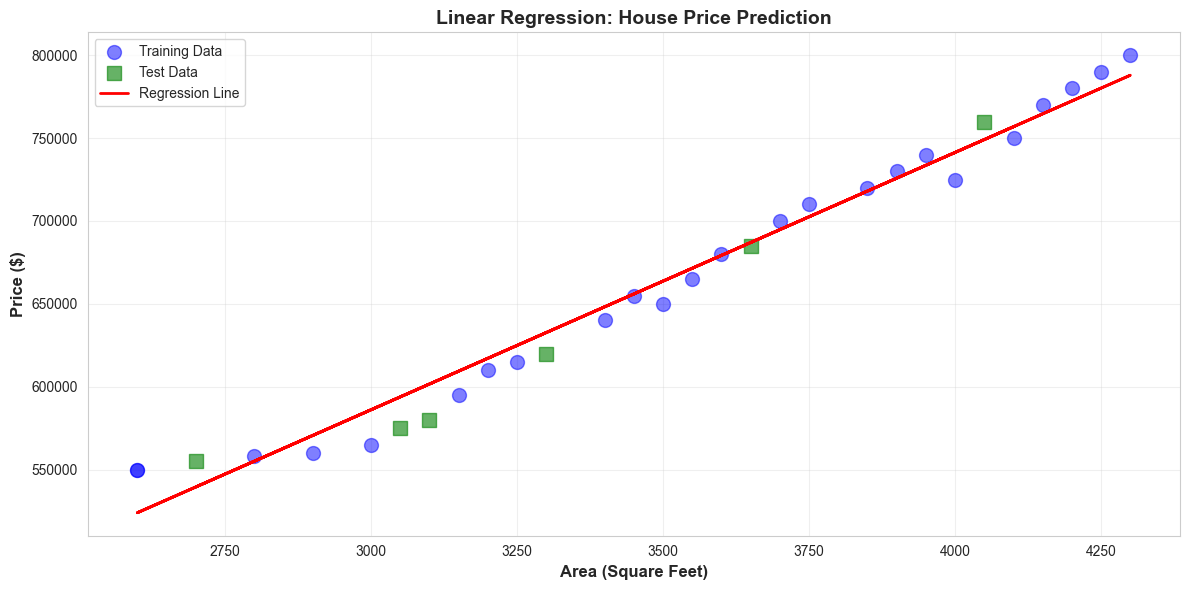

In [14]:
# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data', s=100)

# Plot test data
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test Data', s=100, marker='s')

# Plot regression line
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.xlabel('Area (Square Feet)', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.title('Linear Regression: House Price Prediction', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Evaluation

In [15]:
# Calculate evaluation metrics

# Training set metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test set metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)

print("\n📊 TRAINING SET:")
print(f"  R² Score:          {train_r2:.4f} ({train_r2*100:.2f}% variance explained)")
print(f"  Mean Squared Error (MSE):  ${train_mse:,.2f}")
print(f"  Root MSE (RMSE):   ${train_rmse:,.2f}")
print(f"  Mean Absolute Error (MAE): ${train_mae:,.2f}")

print("\n📊 TEST SET:")
print(f"  R² Score:          {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")
print(f"  Mean Squared Error (MSE):  ${test_mse:,.2f}")
print(f"  Root MSE (RMSE):   ${test_rmse:,.2f}")
print(f"  Mean Absolute Error (MAE): ${test_mae:,.2f}")

print("\n" + "="*60)

if test_r2 > 0.9:
    print("✅ Excellent model performance!")
elif test_r2 > 0.7:
    print("✅ Good model performance!")
else:
    print("⚠️ Model needs improvement")

MODEL PERFORMANCE METRICS

📊 TRAINING SET:
  R² Score:          0.9783 (97.83% variance explained)
  Mean Squared Error (MSE):  $140,095,676.45
  Root MSE (RMSE):   $11,836.20
  Mean Absolute Error (MAE): $9,646.29

📊 TEST SET:
  R² Score:          0.9568 (95.68% variance explained)
  Mean Squared Error (MSE):  $224,389,571.37
  Root MSE (RMSE):   $14,979.64
  Mean Absolute Error (MAE): $13,590.60

✅ Excellent model performance!


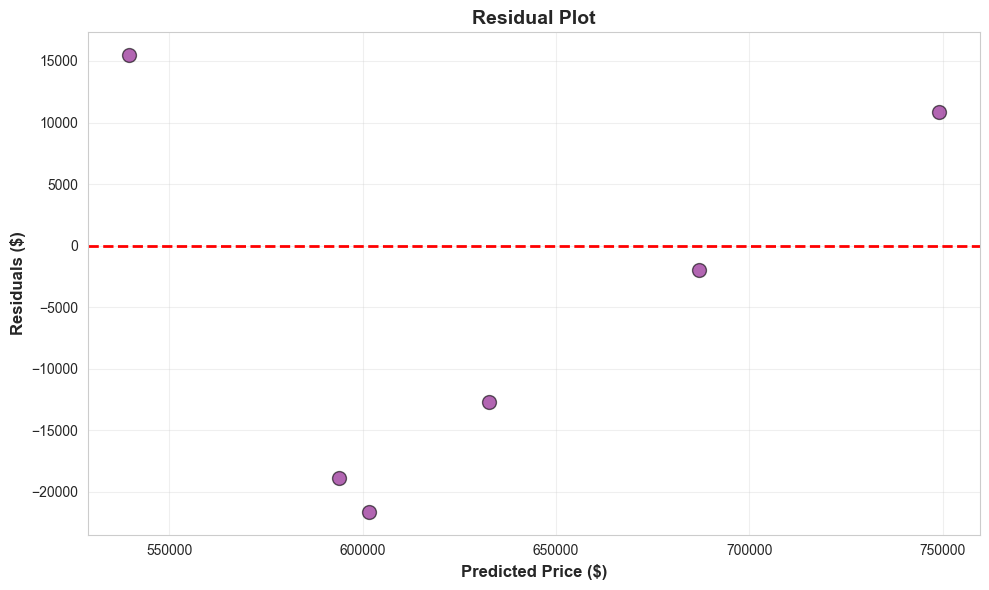


📊 Residual plot shows the errors in prediction.
   Points close to the red line (y=0) indicate good predictions.


In [16]:
# Residual plot (errors)
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, color='purple', alpha=0.6, s=100, edgecolors='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Residuals ($)', fontsize=12, fontweight='bold')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Residual plot shows the errors in prediction.")
print("   Points close to the red line (y=0) indicate good predictions.")

## 8. Make Custom Predictions

In [17]:
# Predict price for custom area values
custom_areas = [[3300], [3750], [4500]]

print("🏠 CUSTOM PREDICTIONS:")
print("="*50)
for area in custom_areas:
    predicted_price = model.predict([area])[0]
    print(f"Area: {area[0]:,} sq ft  →  Predicted Price: ${predicted_price:,.2f}")
print("="*50)

🏠 CUSTOM PREDICTIONS:
Area: 3,300 sq ft  →  Predicted Price: $632,677.90
Area: 3,750 sq ft  →  Predicted Price: $702,539.87
Area: 4,500 sq ft  →  Predicted Price: $818,976.49


C:\Users\SANJAY S\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\SANJAY S\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\SANJAY S\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 9. Save the Trained Model

In [18]:
# Save model to disk
from datetime import datetime

# Create model filename with timestamp and R² score
timestamp = datetime.now().strftime('%Y%m%d')
model_filename = f'house_price_model_{timestamp}_r2_{test_r2:.3f}.pkl'
model_path = Path('../../../models/final/house_prices') / model_filename

# Save the model
joblib.dump(model, model_path)

print(f"✅ Model saved successfully!")
print(f"📁 Location: {model_path}")
print(f"📊 R² Score: {test_r2:.4f}")

✅ Model saved successfully!
📁 Location: ..\..\..\models\final\house_prices\house_price_model_20251205_r2_0.957.pkl
📊 R² Score: 0.9568


## 10. Load and Test Saved Model

In [19]:
# Load the saved model
loaded_model = joblib.load(model_path)

print("✅ Model loaded successfully!")
print("\n🧪 Testing loaded model with new prediction:")

# Test with a new area
test_area = [[3500]]
prediction = loaded_model.predict(test_area)[0]

print(f"\nArea: {test_area[0][0]:,} sq ft")
print(f"Predicted Price: ${prediction:,.2f}")
print("\n✅ Loaded model works perfectly!")

✅ Model loaded successfully!

🧪 Testing loaded model with new prediction:

Area: 3,500 sq ft
Predicted Price: $663,727.66

✅ Loaded model works perfectly!


C:\Users\SANJAY S\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 11. Summary & Key Learnings

### What We Accomplished:
1. ✅ Loaded and explored house price dataset
2. ✅ Visualized the relationship between area and price
3. ✅ Trained a Linear Regression model
4. ✅ Evaluated model performance (R² score, MSE, MAE)
5. ✅ Made predictions on new data
6. ✅ Saved the trained model for future use
7. ✅ Loaded and tested the saved model

### Key Concepts:
- **Linear Regression**: A supervised learning algorithm that models the relationship between input (area) and output (price)
- **R² Score**: Measures how well the model explains the variance in the data (closer to 1 is better)
- **RMSE**: Average prediction error in dollars
- **Train-Test Split**: Separating data to evaluate model on unseen data

### Next Steps:
- Try with multiple features (bedrooms, bathrooms, location)
- Experiment with other algorithms (Ridge, Lasso, Polynomial Regression)
- Collect more data for better predictions
- Deploy the model as a web application